The first step is to collect the data from the Materials Project database using the API key allotted to you.

In [16]:
from mp_api.client import MPRester
import pandas as pd

api_key = "input your API here"

with MPRester(api_key) as mpr:
    # Fetch all binary oxides (any element + O)
    results = mpr.materials.summary.search(
        elements=["O"],              # must contain oxygen
        exclude_elements=[],         # allow all other elements
        num_elements=2,              # binary compounds only
        fields=["material_id", "formula_pretty", "formation_energy_per_atom"]
    )

# Convert results to DataFrame
data_list = []
for r in results:
    data_list.append({
        "material_id": r.material_id,
        "formula": r.formula_pretty,
        "formation_energy_per_atom": r.formation_energy_per_atom
    })

df = pd.DataFrame(data_list)
print(df.head(), len(df))


Retrieving SummaryDoc documents:   0%|          | 0/2548 [00:00<?, ?it/s]

  material_id formula  formation_energy_per_atom
0  mp-1244871     BaO                  -2.619276
1  mp-1244882     CoO                  -0.870093
2  mp-1244902     CaO                  -2.994918
3  mp-1244919     BeO                  -2.838604
4  mp-1244907     BeO                  -2.845417 2548


- pymatgen is a Python library for materials analysis.

- Composition converts a chemical formula (like "LiFePO4") into an object that stores elements and their fractions.

- matminer is a materials data mining library.

- ElementProperty is a featurizer that generates numerical features from elemental properties.

In [17]:
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# Create composition objects
df["composition"] = df["formula"].apply(Composition)

# Use Magpie preset with impute_nan=True
ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)
df_features = ep_feat.featurize_dataframe(df, "composition")

print(df_features.head())


ElementProperty:   0%|          | 0/2548 [00:00<?, ?it/s]

  material_id formula  formation_energy_per_atom composition  \
0  mp-1244871     BaO                  -2.619276     (Ba, O)   
1  mp-1244882     CoO                  -0.870093     (Co, O)   
2  mp-1244902     CaO                  -2.994918     (Ca, O)   
3  mp-1244919     BeO                  -2.838604     (Be, O)   
4  mp-1244907     BeO                  -2.845417     (Be, O)   

   MagpieData minimum Number  MagpieData maximum Number  \
0                        8.0                       56.0   
1                        8.0                       27.0   
2                        8.0                       20.0   
3                        4.0                        8.0   
4                        4.0                        8.0   

   MagpieData range Number  MagpieData mean Number  MagpieData avg_dev Number  \
0                     48.0                    32.0                       24.0   
1                     19.0                    17.5                        9.5   
2                

If you are confused regarding the database listed above, the table given below might give you an idea regarding what is going on - 


| Feature                     | What it represents                                                               |
| --------------------------- | -------------------------------------------------------------------------------- |
| `MagpieData minimum Number` | Minimum atomic number in the formula. BaO → min(56,8) = 8                        |
| `MagpieData maximum Number` | Maximum atomic number in the formula. BaO → max(56,8) = 56                       |
| `MagpieData range Number`   | Range of atomic numbers. BaO → 56 − 8 = 48                                       |
| `MagpieData mean Number`    | Average atomic number. BaO → (56+8)/2 = 32                                       |
| `MagpieData avg_dev Number` | Avg deviation from mean. BaO → ((56-32)+(32-8))/2 = 24                           |
| `MagpieData mode Number`    | Most frequent atomic number. For binary compounds usually one of the two numbers |


Now, we will start the Machine learning part

In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_features.drop(columns=["material_id", "formula", "composition", "formation_energy_per_atom"])
y = df_features["formation_energy_per_atom"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


- X → input features for the machine learning model.

- Remove the remove non numerical

- y → target variable, which is the formation energy per atom (the property you want to predict).

- Now,
    - X → a DataFrame of Magpie features (all numerical).

    - y → a Series of formation energies.
 
- Now split this dataset -

    - test_size=0.2 → 20% of the data will be in the test set, 80% in training.

    - random_state=42 → ensures reproducibility; you always get the same split 

Linear Regression:
  MSE: 0.9673
  R2 : 0.1565

SVR (RBF):
  MSE: 0.4061
  R2 : 0.6459

Random Forest:
  MSE: 0.3901
  R2 : 0.6598



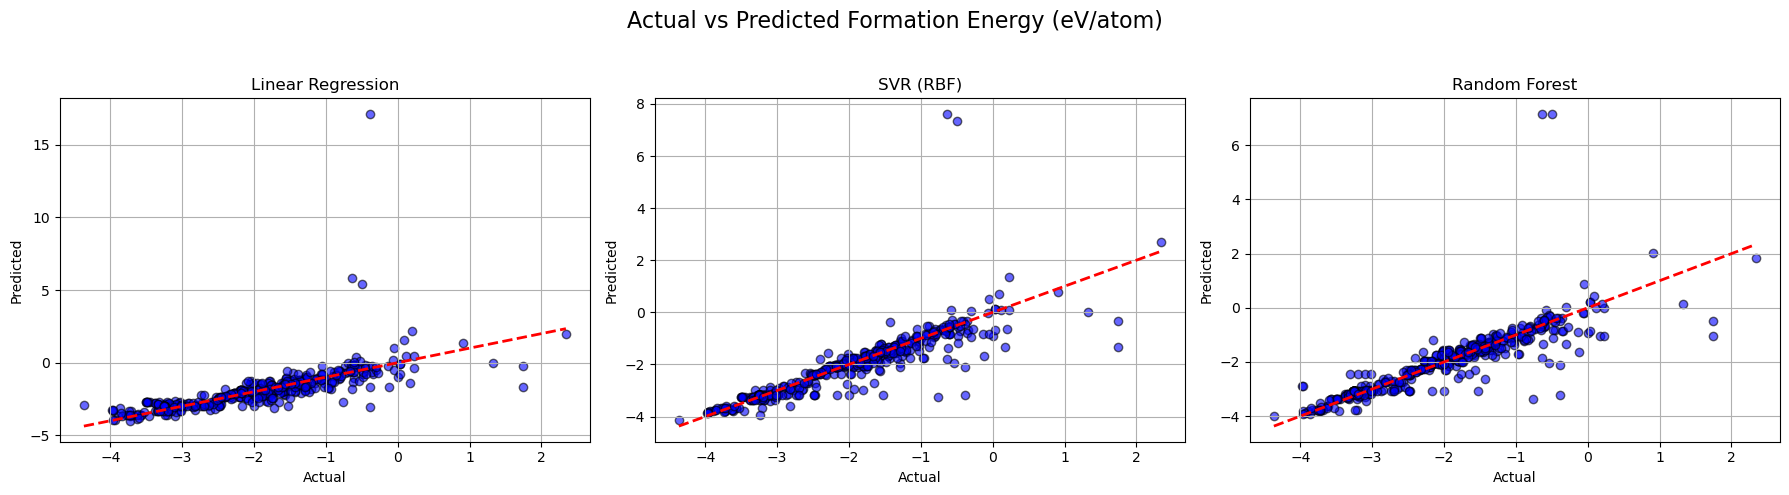

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Scale features for SVR and Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store results
models = {
    "Linear Regression": LinearRegression(),
    "SVR (RBF)": SVR(kernel="rbf", C=10, gamma='scale'),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
}

results = {}

# Train, predict, and evaluate
for name, model in models.items():
    if name == "Random Forest":
        model.fit(X_train_scaled, y_train)  # Random Forest benefits from scaling but can work without
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = (y_pred, mse, r2)
    print(f"{name}:\n  MSE: {mse:.4f}\n  R2 : {r2:.4f}\n")

# Scatter plots
plt.figure(figsize=(18,5))
for i, (name, (y_pred, _, _)) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name}")
    plt.grid(True)

plt.suptitle("Actual vs Predicted Formation Energy (eV/atom)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


   - LinearRegression → simple linear model
    
   - SVR → Support Vector Regression with RBF kernel
    
   - RandomForestRegressor → ensemble of decision trees
    
   - StandardScaler → normalizes features to mean=0, std=1
    
   - mean_squared_error & r2_score → metrics for regression evaluation
    
   - matplotlib.pyplot → plotting library


- fit_transform → computes mean & std on training set and scales it

- transform → scales test set using same parameters as training set

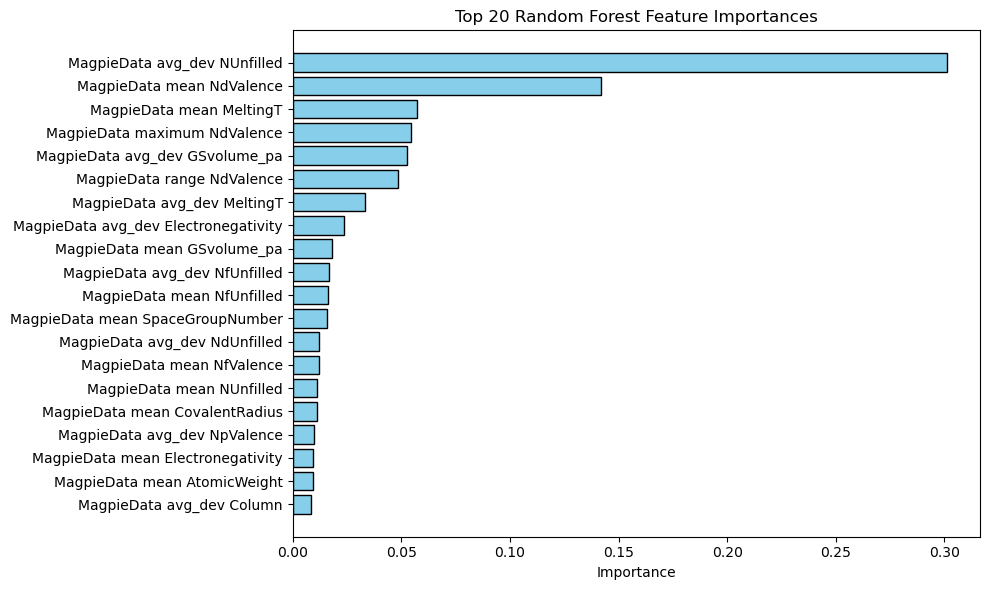

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df["feature"].head(20)[::-1], feat_imp_df["importance"].head(20)[::-1], color='skyblue', edgecolor='k')
plt.xlabel("Importance")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()
